# Polymarket Daily BTC Price-Range Markets

This notebook analyses Polymarket's "Will the price of Bitcoin be between $X and $Y on date D?" markets.

For each resolution date the order book is sliced into mutually-exclusive $2k bands.
The Yes price of each band is the market-implied probability that BTC's closing price
will fall inside that band.

**Steps**

1. Combine the per-(date, band) parquet files into two consolidated tables: one for the
   minute-by-minute Yes price history, one for the aggregated trades.
2. Build a discrete market-implied distribution of BTC closing price at every minute and
   fit a lognormal to extract implied volatility as a function of time-to-resolution.
3. Heatmap of bands coloured by market price (probability).
4. Test market efficiency: compare the market-implied probabilities at 1 day / 12 h /
   4 h before resolution against the empirical hit rate (calibration / reliability plot).


In [1]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 1. Load Data


In [2]:
COMBINED_DIR = Path('01 Data Extraction/Data/BTC Reach Daily Combined')

# prices_extended.parquet covers the full ~7-day market lifetime (vs 24 h in
# prices.parquet). Trade data (trades.parquet) remains capped at 24 h before
# resolution — the lookback justification is in section 2.b below.
prices = pd.read_parquet('data/prices_extended.parquet')
trades = pd.read_parquet('data/trades.parquet')
summaries = pd.read_parquet('data/market_summary.parquet')

## 2. Build the Yes-price panel and identify the settled band

For each market the Yes outcome carries the market-implied probability that BTC closes
inside the band.  We pivot the data into a `(date, timestamp, band)` panel of Yes prices
and recover the settlement band as the one whose Yes outcome ultimately settled at 1.


In [3]:
# Yes-only minute-by-minute panel
yes = prices[prices["outcome_label"] == "Yes"].copy()
yes["band_mid"] = (yes["lower_price"] + yes["upper_price"]) / 2.0
yes["target_date"] = pd.to_datetime(yes["target_date"], utc=True).dt.normalize()
yes["timestamp"] = pd.to_datetime(yes["timestamp"], utc=True)
yes["minutes_to_resolution"] = (
    (yes["market_end_date"] - yes["timestamp"]).dt.total_seconds() / 60.0
)
print(f"Yes panel : {yes.shape[0]:,} rows")
print(f"Dates     : {yes['target_date'].nunique()}  "
      f"({yes['target_date'].min().date()} -> {yes['target_date'].max().date()})")
print(f"Bands/day : {yes.groupby('target_date')['price_band_label'].nunique().describe().round(2).to_dict()}")

# Settlement: the Yes outcome row whose final outcome_price == 1
settle = (yes.groupby(["target_date", "price_band_label"], as_index=False)
              .agg(lower_price=("lower_price", "first"),
                   upper_price=("upper_price", "first"),
                   band_mid=("band_mid", "first"),
                   outcome_price=("outcome_price", "last")))
winners = settle[settle["outcome_price"] == 1]
print(f"\nResolved days with a winning band: {winners['target_date'].nunique()}")

# Per-day settlement summary: which band won
settled_band = (winners.set_index("target_date")
                       [["price_band_label", "lower_price", "upper_price", "band_mid"]]
                       .rename(columns={"price_band_label": "settled_band",
                                        "lower_price": "settled_lower",
                                        "upper_price": "settled_upper",
                                        "band_mid": "settled_mid"}))
settled_band.head()


Yes panel : 7,293,195 rows
Dates     : 81  (2025-11-01 -> 2026-01-21)


Bands/day : {'count': 81.0, 'mean': 8.99, 'std': 0.11, 'min': 8.0, '25%': 9.0, '50%': 9.0, '75%': 9.0, 'max': 9.0}



Resolved days with a winning band: 71


,settled_band,settled_lower,settled_upper,settled_mid
target_date,,,,
2025-11-01 00:00:00+00:00,110k-112k,110000,112000,111000.0
2025-11-02 00:00:00+00:00,110k-112k,110000,112000,111000.0
2025-11-03 00:00:00+00:00,106k-108k,106000,108000,107000.0
2025-11-05 00:00:00+00:00,102k-104k,102000,104000,103000.0
2025-11-06 00:00:00+00:00,100k-102k,100000,102000,101000.0


### 2.b Trade volume vs time-to-resolution — lookback choice

Polymarket daily BTC range markets are open for approximately **7 days** before
resolution. The `prices_extended.parquet` data covers this entire window
($\approx 168\,\text{h}$) using the CLOB order-book timeseries API.
However, the `trades.parquet` (actual executed trades, minute-aggregated) is
limited to the **last 24 h** of each market — this is the window in which
liquidity is sufficient to validate quoted prices against transaction flow.

The plot below shows how trading volume ($\text{USDC}$) is distributed across
the 24 h before resolution. This informs our choice of temporal bins:

* **Fine 4 h bins** for the last 24 h, where trade data exists and volume is
  concentrated (the last 4 h alone account for ~59 % of all 24 h volume).
* **Coarser bins** beyond 24 h (`[24,48)`, `[48,72)`, `[72,120)`, `[120,168)`)
  where only CLOB price history is available but the term structure of implied
  volatility and the smile shape are still identifiable.

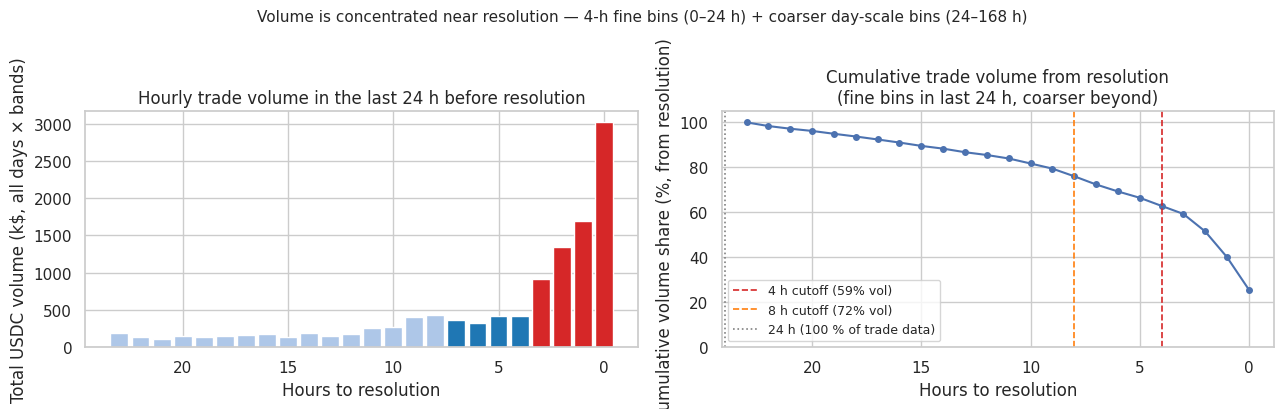

Median daily 24-h total USDC volume: $147,540
Volume share: last  4 h = 59.3%
Volume share: last  8 h = 72.4%
Volume share: last 24 h = 100.0%  (full trade-data window)

Chosen temporal bins:
  Fine  (trade data):  [0,4), [4,8), [8,12), [12,16), [16,20), [20,24) h
  Coarse (CLOB only):  [24,48), [48,72), [72,120), [120,168) h


In [4]:
# ── Volume per hour bin, aggregated over all days and bands ─────────────────
yes_t = trades[trades["outcome_label"] == "Yes"].copy()
yes_t["ttr_h"] = (yes_t["market_end_date"] - yes_t["timestamp"]).dt.total_seconds() / 3600.0
yes_t["ttr_bin_h"] = yes_t["ttr_h"].apply(lambda x: min(int(x), 23))

vol_by_hour = (yes_t.groupby("ttr_bin_h")["volume_usdc"].sum()
                    .reindex(range(24), fill_value=0)
                    .sort_index())
total_vol = vol_by_hour.sum()
# Cumulative volume from resolution (sum of hours 0..h before resolution)
cum_from_res = vol_by_hour.sort_index().cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = ["#d62728" if h < 4 else "#1f77b4" if h < 8 else "#aec7e8" for h in vol_by_hour.index]
ax.bar(vol_by_hour.index, vol_by_hour.values / 1e3, color=colors, edgecolor="white", width=0.85)
ax.invert_xaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Total USDC volume (k$, all days × bands)")
ax.set_title("Hourly trade volume in the last 24 h before resolution")
ax.annotate("59 % of volume\n in last 4 h", xy=(2, vol_by_hour[:4].sum()/1e3*0.5),
            xytext=(6, vol_by_hour[:4].sum()/1e3*0.7), fontsize=9, color="#d62728",
            arrowprops=dict(arrowstyle="-|>", color="#d62728"))

ax = axes[1]
ax.plot(cum_from_res.index, cum_from_res.values / total_vol * 100, "-o", color="C0", ms=4)
pct4 = vol_by_hour[:4].sum()/total_vol*100
pct8 = vol_by_hour[:8].sum()/total_vol*100
ax.axvline(4,  color="#d62728", ls="--", lw=1.2, label=f"4 h cutoff ({pct4:.0f}% vol)")
ax.axvline(8,  color="#ff7f0e", ls="--", lw=1.2, label=f"8 h cutoff ({pct8:.0f}% vol)")
ax.axvline(24, color="grey",    ls=":",  lw=1.2, label="24 h (100 % of trade data)")
ax.invert_xaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Cumulative volume share (%, from resolution)")
ax.set_title("Cumulative trade volume from resolution\n(fine bins in last 24 h, coarser beyond)")
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

plt.suptitle(
    "Volume is concentrated near resolution — 4-h fine bins (0–24 h) + coarser day-scale bins (24–168 h)",
    y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print(f"Median daily 24-h total USDC volume: ${yes_t.groupby('target_date')['volume_usdc'].sum().median():,.0f}")
print(f"Volume share: last  4 h = {vol_by_hour[:4].sum()/total_vol*100:.1f}%")
print(f"Volume share: last  8 h = {vol_by_hour[:8].sum()/total_vol*100:.1f}%")
print(f"Volume share: last 24 h = {100.0:.1f}%  (full trade-data window)")
print()
print("Chosen temporal bins:")
print("  Fine  (trade data):  [0,4), [4,8), [8,12), [12,16), [16,20), [20,24) h")
print("  Coarse (CLOB only):  [24,48), [48,72), [72,120), [120,168) h")


In [5]:
# Extended temporal bins used throughout the rest of this notebook.
# Calibration (Section 5) is restricted to the first six 4-h bins where trade
# data is available; all other analyses use the full extended window.
BUCKET_EDGES_FINE     = [0, 4, 8, 12, 16, 20, 24]           # trade-data window
BUCKET_EDGES_EXTENDED = [0, 4, 8, 12, 16, 20, 24, 48, 72, 120, 168]  # full market lifetime

# Convenience: list of (lo_h, hi_h, label) for each bucket
lookbacks_fine     = [(lo, hi, f"{lo}-{hi} h")
                      for lo, hi in zip(BUCKET_EDGES_FINE[:-1],     BUCKET_EDGES_FINE[1:])]
lookbacks_extended = [(lo, hi, f"{lo}-{hi} h")
                      for lo, hi in zip(BUCKET_EDGES_EXTENDED[:-1], BUCKET_EDGES_EXTENDED[1:])]

# For the smile + calibration we expose a single `lookbacks` variable; each
# consumer overrides it locally when it needs the other set.
lookbacks = lookbacks_extended

def snapshot_in_window(lo_h, hi_h, src_df=None):
    """Average Yes price per (date, band) across all snapshots with ttr in [lo_h, hi_h)."""
    df = yes_15m if src_df is None else src_df
    ttr_h = df["minutes_to_resolution"] / 60.0
    g = df[(ttr_h >= lo_h) & (ttr_h < hi_h)]
    if g.empty:
        return g.iloc[0:0].copy()
    return (g.groupby(["target_date", "lower_price", "upper_price"], as_index=False)
              .agg(price=("price", "mean"),
                   n_minutes=("price", "size")))


## 3. Heatmap of bands coloured by Yes price

The colour of cell `(t, band)` is the market-implied probability that BTC closes inside
that band, where `t` is the time-to-resolution (in hours) and bands are stacked by their
lower price.  We plot four representative days and one aggregate view in which bands have
been re-centred on the eventually-realised band so cross-day averages are meaningful.


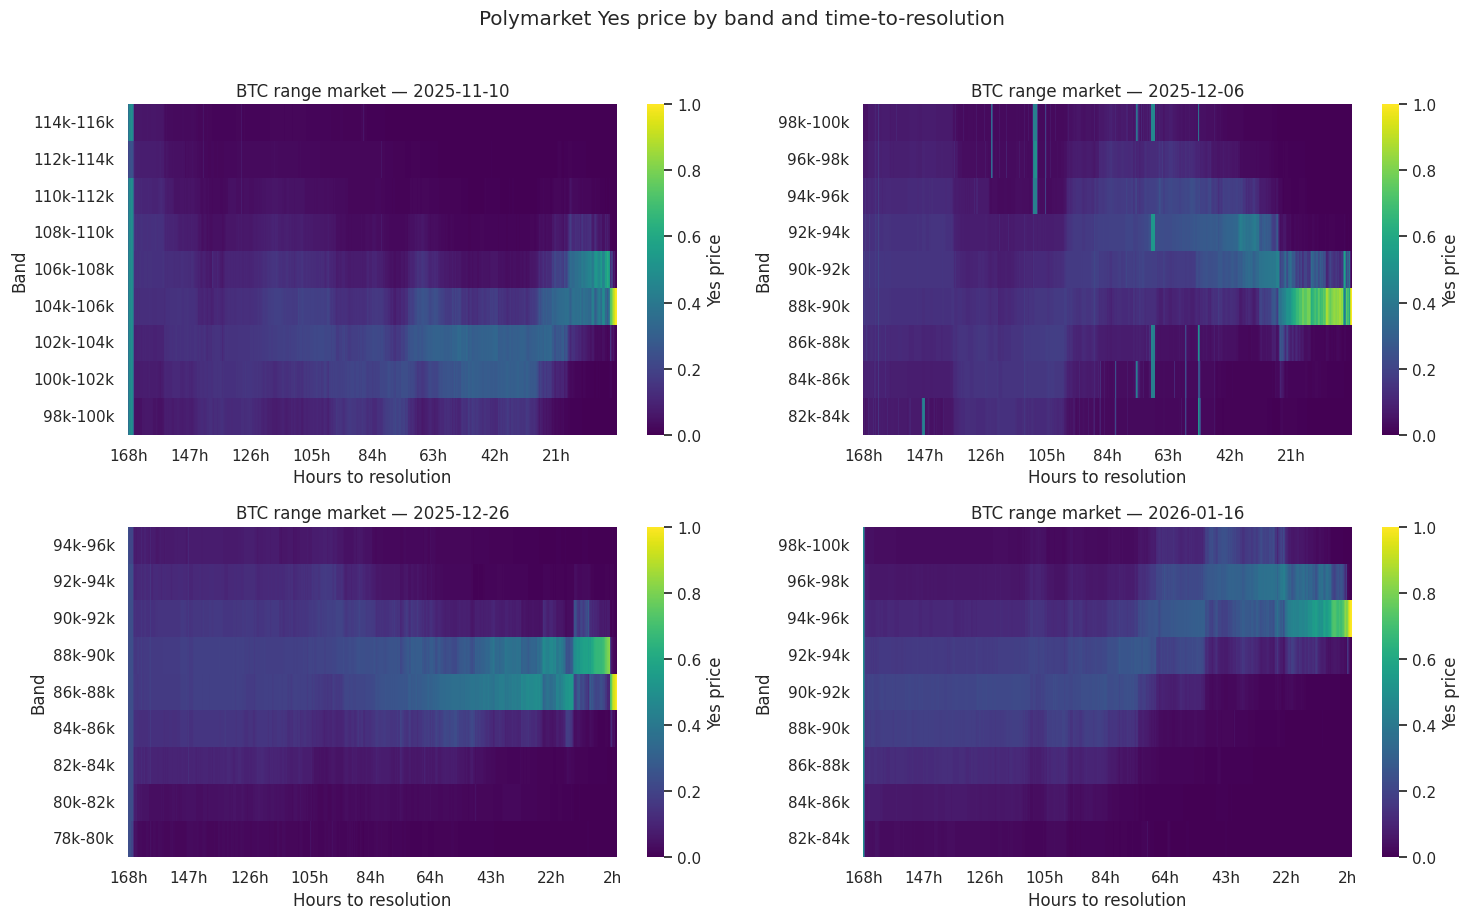

In [6]:
# Resample to a coarser grid so heatmaps render quickly: 15-minute buckets
yes_15m = yes.copy()
yes_15m["ttr_h"] = yes_15m["minutes_to_resolution"] / 60.0
yes_15m["ttr_bin"] = (yes_15m["ttr_h"] / 0.25).round() * 0.25  # 15 min

def _day_heatmap(day, ax):
    g = yes_15m[yes_15m["target_date"] == day]
    pivot = (g.groupby(["lower_price", "ttr_bin"])["price"]
              .mean().unstack("ttr_bin"))
    pivot = pivot.sort_index(ascending=True)
    # Sort columns by ttr descending so the resolution moment is on the right
    pivot = pivot[sorted(pivot.columns, reverse=True)]
    yticks = [f"{int(lo/1000)}k-{int((lo+2000)/1000)}k" for lo in pivot.index]
    sns.heatmap(pivot.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
                cbar_kws={"label": "Yes price"})
    ax.set_yticks(np.arange(len(yticks)) + 0.5)
    ax.set_yticklabels(yticks, rotation=0)
    # x-ticks: show every ~4h
    cols = pivot.columns.to_numpy()
    step = max(1, len(cols) // 8)
    ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
    ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
    ax.invert_yaxis()
    ax.set_xlabel("Hours to resolution")
    ax.set_ylabel("Band")
    ax.set_title(f"BTC range market — {pd.Timestamp(day).date()}")

sample_days = (settled_band.index
               .intersection(yes_15m["target_date"].unique()))
# Pick four well-separated days
sample_days = sorted(sample_days)
sample_days = [sample_days[i] for i in np.linspace(5, len(sample_days)-5, 4).astype(int)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for d, ax in zip(sample_days, axes.ravel()):
    _day_heatmap(d, ax)
fig.suptitle("Polymarket Yes price by band and time-to-resolution", y=1.02)
fig.tight_layout()
plt.show()


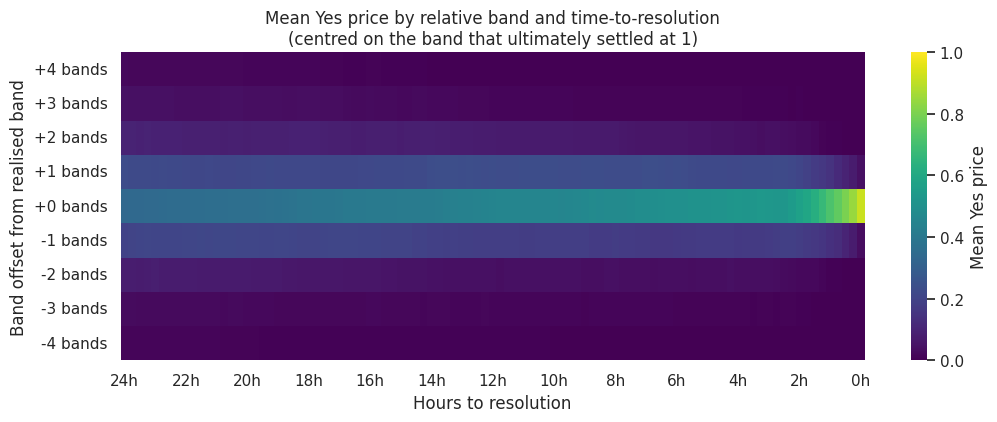

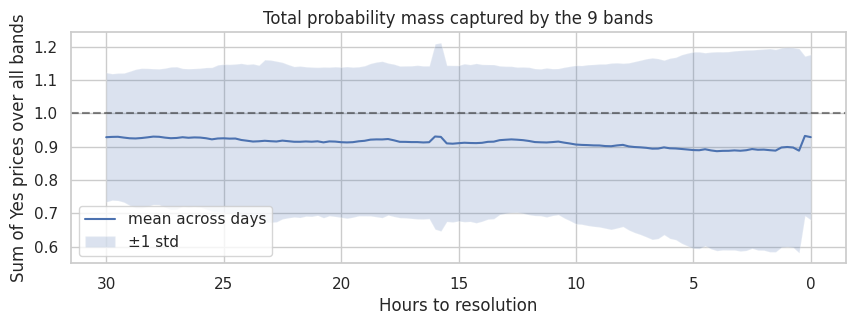

In [7]:
# Aggregate heatmap: re-centre bands on the eventually-realised band so we can
# average across days.  The y-axis is the band offset (in $2k steps) from the
# winning band; the colour is the average Yes price across the days where that
# relative band existed.

resolved_yes = yes_15m.merge(
    settled_band[["settled_mid"]], left_on="target_date", right_index=True, how="inner")
resolved_yes["rel_band"] = ((resolved_yes["band_mid"] - resolved_yes["settled_mid"]) / 2000).round().astype(int)

agg = (resolved_yes.groupby(["rel_band", "ttr_bin"])["price"]
                   .mean().unstack("ttr_bin"))
agg = agg.sort_index()
agg = agg[sorted(agg.columns, reverse=True)]

# Restrict to dense region
agg = agg.loc[(agg.index >= -4) & (agg.index <= 4)]
agg = agg.loc[:, agg.columns <= 24]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(agg.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "Mean Yes price"})
cols = agg.columns.to_numpy()
step = max(1, len(cols) // 12)
ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
ax.set_yticks(np.arange(len(agg.index)) + 0.5)
ax.set_yticklabels([f"{b:+d} bands" for b in agg.index], rotation=0)
ax.invert_yaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Band offset from realised band")
ax.set_title("Mean Yes price by relative band and time-to-resolution\n"
             "(centred on the band that ultimately settled at 1)")
plt.show()

# Sanity check: probabilities should sum to ~1 across bands at each instant.
# We first average within each (date, ttr_bin, band) cell, then sum across bands.
band_sum = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price"])["price"].mean()
                   .groupby(["target_date", "ttr_bin"]).sum()
                   .groupby("ttr_bin").agg(["mean", "std"]))
band_sum = band_sum.sort_index()
band_sum = band_sum[band_sum.index.to_series().between(0, 30)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(band_sum.index, band_sum["mean"], label="mean across days")
ax.fill_between(band_sum.index,
                band_sum["mean"] - band_sum["std"],
                band_sum["mean"] + band_sum["std"], alpha=0.2,
                label="±1 std")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Sum of Yes prices over all bands")
ax.set_title("Total probability mass captured by the 9 bands")
ax.legend()
ax.invert_xaxis()
plt.show()


## 4. Implied volatility vs time-to-resolution

At every minute Polymarket gives us a discrete CDF of BTC's closing price.  Fitting a
lognormal $\ln S_T \sim \mathcal{N}(\mu, \sigma^2)$ to those band probabilities lets us
recover an implied volatility:

$$ p_i \approx \Phi\!\left(\frac{\ln U_i - \mu}{\sigma}\right) - \Phi\!\left(\frac{\ln L_i - \mu}{\sigma}\right). $$

We minimise the sum of squared errors over the bands at every 15-minute snapshot, then
annualise with $\sigma_{\text{IV}} = \sigma / \sqrt{\tau_y}$.


In [8]:
def fit_lognormal(lowers, uppers, probs):
    """Return (mu, sigma) minimising squared distance between bands and lognormal."""
    lowers = np.asarray(lowers, dtype=float)
    uppers = np.asarray(uppers, dtype=float)
    probs = np.asarray(probs, dtype=float)
    ln_lo = np.log(np.maximum(lowers, 1.0))
    ln_hi = np.log(uppers)
    # Spot guess: probability-weighted band mid
    mid = (lowers + uppers) / 2.0
    s = probs.sum()
    spot = float((mid * probs).sum() / s) if s > 0 else float(mid.mean())
    mu0 = np.log(spot)
    sig0 = 0.02
    def loss(theta):
        mu, log_sig = theta
        sig = np.exp(log_sig)
        cdf_hi = norm.cdf((ln_hi - mu) / sig)
        cdf_lo = norm.cdf((ln_lo - mu) / sig)
        pred = cdf_hi - cdf_lo
        return float(np.sum((pred - probs) ** 2))
    res = minimize(loss, x0=[mu0, np.log(sig0)], method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-8, "maxiter": 400})
    mu, log_sig = res.x
    return mu, float(np.exp(log_sig)), res.fun


# Aggregate to one row per (target_date, ttr_bin, band)
snap = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price", "upper_price"],
                        as_index=False)["price"].mean())

# Need market_end_date per (target_date, ttr_bin) -> ttr_bin already encodes time-to-resolution.
# Only fit snapshots where:
#   - there is non-trivial probability mass (sum>0.5)
#   - we have at least 4 bands
#   - 0 < ttr_h < 30
fit_records = []
groups = snap.groupby(["target_date", "ttr_bin"])
for (day, ttr_h), g in groups:
    # Cap IV fit at 48 h: beyond that the 4-h-bin resolution yields the same
    # information as the smile bucket analysis, while fitting every bin out to
    # 168 h would require ~15 min of compute.
    if ttr_h <= 0 or ttr_h > 48:
        continue
    if len(g) < 4 or g["price"].sum() < 0.5:
        continue
    mu, sigma, err = fit_lognormal(g["lower_price"].values,
                                   g["upper_price"].values,
                                   g["price"].values)
    fit_records.append({
        "target_date": day,
        "ttr_h": ttr_h,
        "mu": mu,
        "spot_implied": np.exp(mu),
        "sigma_h": sigma,
        "fit_err": err,
        "prob_mass": g["price"].sum(),
    })

iv = pd.DataFrame(fit_records)
iv["tau_years"] = iv["ttr_h"] / 24.0 / 365.0
iv["iv_annual"] = iv["sigma_h"] / np.sqrt(iv["tau_years"])
print(f"Fitted {len(iv):,} snapshots across {iv['target_date'].nunique()} days")
iv.head()


Fitted 14,279 snapshots across 81 days


,target_date,ttr_h,mu,spot_implied,sigma_h,fit_err,prob_mass,tau_years,iv_annual
0,2025-11-01 00:00:00+00:00,0.25,11.611457,110354.904542,0.005035,0.000004,1.000467,0.000029,0.942580
1,2025-11-01 00:00:00+00:00,0.50,11.610786,110280.935363,0.005456,0.000005,1.000300,0.000057,0.722111
2,2025-11-01 00:00:00+00:00,0.75,11.613187,110545.960418,0.004817,0.000011,1.000700,0.000086,0.520555
3,2025-11-01 00:00:00+00:00,1.00,11.607058,109870.531886,0.005342,0.000012,1.009300,0.000114,0.499968
4,2025-11-01 00:00:00+00:00,1.25,11.606448,109803.541282,0.005360,0.000010,1.008633,0.000143,0.448746


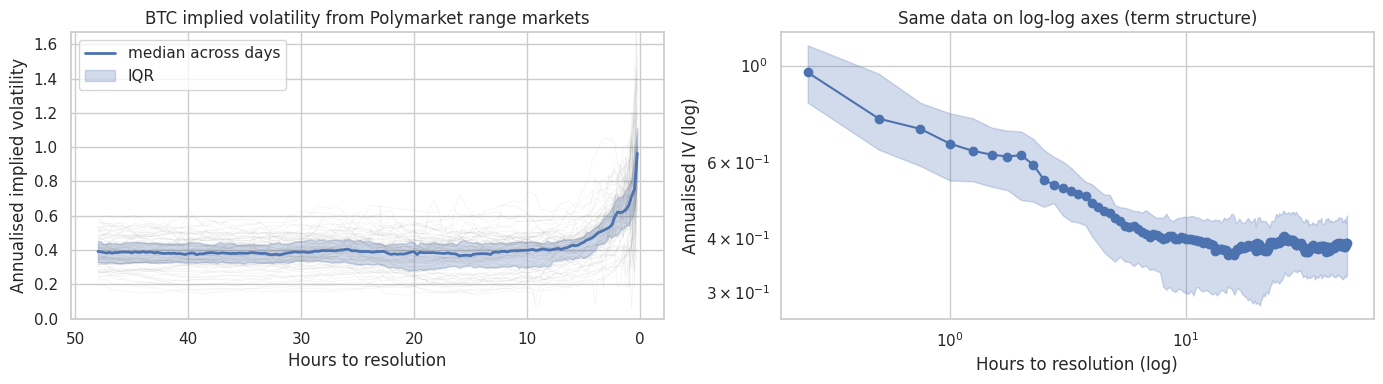

IV at   48h to resolution: 39.1%  (n=78 snapshots)
IV at   24h to resolution: 39.1%  (n=74 snapshots)
IV at   12h to resolution: 39.2%  (n=74 snapshots)
IV at    4h to resolution: 48.3%  (n=72 snapshots)
IV at    1h to resolution: 66.1%  (n=72 snapshots)


In [9]:
# Plot IV vs time-to-resolution.  We aggregate across days into the median and
# inter-quartile band per ttr bin.
iv_q = (iv.groupby("ttr_h")["iv_annual"]
          .agg(median="median", q25=lambda s: s.quantile(0.25),
               q75=lambda s: s.quantile(0.75), n="count")
          .reset_index())
iv_q = iv_q[iv_q["n"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for d, g in iv.groupby("target_date"):
    ax.plot(g["ttr_h"], g["iv_annual"], color="grey", alpha=0.1, lw=0.5)
ax.plot(iv_q["ttr_h"], iv_q["median"], color="C0", lw=2, label="median across days")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25,
                label="IQR")
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Annualised implied volatility")
ax.set_title("BTC implied volatility from Polymarket range markets")
ax.set_ylim(0, min(2.5, iv_q["q75"].max() * 1.5))
ax.invert_xaxis()
ax.legend()

ax = axes[1]
ax.plot(iv_q["ttr_h"], iv_q["median"], "o-", color="C0")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Hours to resolution (log)")
ax.set_ylabel("Annualised IV (log)")
ax.set_title("Same data on log-log axes (term structure)")

plt.tight_layout()
plt.show()

for ref_h in [48, 24, 12, 4, 1]:
    row = iv_q.loc[(iv_q["ttr_h"] - ref_h).abs().idxmin()]
    print(f"IV at {ref_h:4d}h to resolution: {row['median']*100:.1f}%  (n={int(row['n'])} snapshots)")


### 4.b Why a lognormal? Link with implied volatility in options, and richer fits

**Why lognormal first.**  The lognormal is the canonical baseline because (i) it is the
benchmark distribution of the Black–Scholes model (GBM dynamics
$dS/S = \mu\,dt + \sigma\,dW$), (ii) it has only two parameters (location and scale),
which exactly matches what one can identify from a *single* implied vol number, and
(iii) for short horizons ($\tau \lesssim 1\text{d}$) it is a very good local
approximation to virtually any continuous price process – higher moments only become
material on longer horizons.

**Link with traditional implied volatility.**  In options markets, an *implied
volatility* is the unique $\sigma$ that makes the Black–Scholes price equal the
observed option price.  Here we do something equivalent but with *digital* payoffs:
a Polymarket "Yes" contract on band $[L,U]$ is economically a *butterfly* of two
digital calls:

$$\text{Yes}_{[L,U]} = \mathbf{1}\{S_T>L\} - \mathbf{1}\{S_T>U\}.$$

Under Black-Scholes with zero rate, a digital call on $K$ has price
$N(d_2(K,\sigma))$, so the band price is
$N(d_2(L,\sigma)) - N(d_2(U,\sigma))$.  Fitting a single $\sigma$ to *all* bands is
exactly fitting the lognormal CDF, and the resulting number is directly comparable to
the at-the-money implied vol on a CME / Deribit BTC option of the same maturity.  If
the bands disagree on $\sigma$ – the *smile* – the market is telling us BTC's risk-
neutral distribution is non-lognormal (heavy tails, skew, …).

**Going beyond two parameters.**  We extend the fit with a *skew-normal on
log-returns*: $\ln S_T \sim \mathrm{SN}(\xi, \omega, \alpha)$.  The third parameter
$\alpha$ captures skewness; positive $\alpha$ means more mass in the right tail.  A
Johnson-$S_U$ (4 parameters) would additionally capture excess kurtosis, but with
only 9 band probabilities per snapshot the skew-normal is already at the edge of
identifiability.


skew-normal fit:   0%|          | 0/13653 [00:00<?, ?snap/s]

Mean SSE  lognormal  : 0.00051
Mean SSE  skew-normal: 0.00049
Skew-normal strictly improves on 81.9% of snapshots


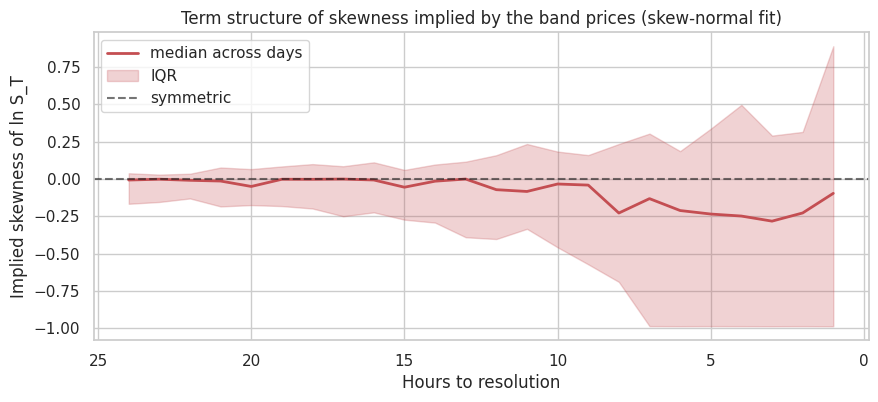

In [10]:
from scipy.special import owens_t
from tqdm.auto import tqdm

# Fast closed-form skew-normal CDF: F(x; xi, omega, alpha) = Phi(z) - 2 T(z, alpha),
# z = (x - xi)/omega.  scipy.stats.skewnorm.cdf silently falls back to numerical
# integration in the tails (a>0, cdf<1e-6); replacing it with this vectorised
# expression makes a single evaluation ~1 µs instead of ~ms.
def _sn_cdf(x, xi, omega, alpha):
    z = (x - xi) / omega
    return norm.cdf(z) - 2.0 * owens_t(z, alpha)


def _moment_init(lowers, uppers, probs):
    """Method-of-moments seed for the skew-normal fit (on ln S_T)."""
    ln_mid = (np.log(np.maximum(lowers, 1.0)) + np.log(uppers)) / 2.0
    s = probs.sum()
    if s <= 0:
        return np.log((lowers.mean() + uppers.mean()) / 2), 0.02, 0.0
    w = probs / s
    m = float((w * ln_mid).sum())
    v = float((w * (ln_mid - m) ** 2).sum())
    sd = max(np.sqrt(max(v, 1e-12)), 1e-6)
    g = float((w * ((ln_mid - m) / sd) ** 3).sum())          # sample skewness
    target = np.clip(abs(g), 1e-3, 0.99)
    ds = np.linspace(1e-3, 0.999, 200)
    gs = ((4 - np.pi) / 2) * (ds * np.sqrt(2/np.pi)) ** 3 \
         / (1 - 2 * ds ** 2 / np.pi) ** 1.5
    delta = float(np.sign(g) * ds[np.abs(gs - target).argmin()])
    alpha = delta / np.sqrt(max(1 - delta ** 2, 1e-9))
    omega = sd / np.sqrt(max(1 - 2 * delta ** 2 / np.pi, 1e-6))
    xi = m - omega * delta * np.sqrt(2 / np.pi)
    return xi, omega, alpha


def fit_skewnormal(lowers, uppers, probs):
    """Fit ln S_T ~ SkewNormal(xi, omega, alpha) to band probabilities."""
    lowers = np.asarray(lowers, float); uppers = np.asarray(uppers, float)
    probs = np.asarray(probs, float)
    ln_lo = np.log(np.maximum(lowers, 1.0)); ln_hi = np.log(uppers)
    xi0, om0, al0 = _moment_init(lowers, uppers, probs)

    def loss(theta):
        xi, log_om, alpha = theta
        om = np.exp(log_om)
        pred = _sn_cdf(ln_hi, xi, om, alpha) - _sn_cdf(ln_lo, xi, om, alpha)
        return float(np.sum((pred - probs) ** 2))

    x0 = [xi0, np.log(max(om0, 1e-4)), float(al0)]
    res = minimize(loss, x0, method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-9, "maxiter": 300})
    xi, log_om, alpha = res.x
    return xi, float(np.exp(log_om)), float(alpha), float(res.fun)


# Subsample: fit one snapshot per hour to keep the cell quick.
snap_h = snap.copy()
snap_h["ttr_h_int"] = snap_h["ttr_bin"].round().astype(int)
snap_h = (snap_h.groupby(["target_date", "ttr_h_int", "lower_price", "upper_price"],
                         as_index=False)["price"].mean())

snap_groups = list(snap_h.groupby(["target_date", "ttr_h_int"]))
sn_records = []
for (day, ttr_h), g in tqdm(snap_groups, desc="skew-normal fit", unit="snap"):
    if ttr_h <= 0 or ttr_h > 24 or len(g) < 5 or g["price"].sum() < 0.5:
        continue
    xi, om, alpha, err = fit_skewnormal(g["lower_price"].values,
                                        g["upper_price"].values,
                                        g["price"].values)
    delta = alpha / np.sqrt(1 + alpha ** 2)
    g_sn = ((4 - np.pi) / 2) * (delta * np.sqrt(2/np.pi)) ** 3 \
           / max((1 - 2 * delta ** 2 / np.pi) ** 1.5, 1e-9)
    sn_records.append({"target_date": day, "ttr_h": float(ttr_h),
                       "xi": xi, "omega": om, "alpha": alpha,
                       "skewness_logS": g_sn, "fit_err": err})

iv_sn = pd.DataFrame(sn_records)
iv_sn["tau_years"] = iv_sn["ttr_h"] / 24.0 / 365.0
iv_sn["iv_annual_sn"] = iv_sn["omega"] / np.sqrt(iv_sn["tau_years"])

# Compare fit quality vs the lognormal on the matching subsampled grid
iv_h = (iv.assign(ttr_h_int=iv["ttr_h"].round().astype(int))
          .groupby(["target_date", "ttr_h_int"], as_index=False)
          .agg(fit_err_logn=("fit_err", "mean")))
cmp = iv_sn.merge(iv_h, left_on=["target_date", "ttr_h"],
                  right_on=["target_date", "ttr_h_int"], how="inner")
print(f"Mean SSE  lognormal  : {cmp['fit_err_logn'].mean():.5f}")
print(f"Mean SSE  skew-normal: {cmp['fit_err'].mean():.5f}")
print(f"Skew-normal strictly improves on {(cmp['fit_err'] < cmp['fit_err_logn']-1e-6).mean()*100:.1f}% of snapshots")

# Term structure of implied skewness
sk_q = (iv_sn.groupby("ttr_h")["skewness_logS"]
              .agg(median="median",
                   q25=lambda s: s.quantile(0.25),
                   q75=lambda s: s.quantile(0.75),
                   n="count").reset_index())
sk_q = sk_q[sk_q["n"] >= 10]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sk_q["ttr_h"], sk_q["median"], lw=2, color="C3", label="median across days")
ax.fill_between(sk_q["ttr_h"], sk_q["q25"], sk_q["q75"], color="C3", alpha=0.25,
                label="IQR")
ax.axhline(0, color="k", linestyle="--", alpha=0.6, label="symmetric")
ax.set_xlabel("Hours to resolution"); ax.set_ylabel("Implied skewness of ln S_T")
ax.set_title("Term structure of skewness implied by the band prices (skew-normal fit)")
ax.invert_xaxis(); ax.legend()
plt.show()


### 4.c Implied volatility smile

The lognormal fit collapses the whole band structure onto a single $\sigma$.  If the
market really thinks BTC is lognormal, every band must imply the *same* $\sigma$ —
the "smile" is flat.  We invert each band boundary one by one and plot
$\sigma_{\text{BS}}(K)$ as a function of log-moneyness $m=\ln(K/S_t)$.

For a digital call paying \$1 if $S_T>K$, Black–Scholes with zero rate gives the
price $N(d_2)$ with $d_2 = \bigl(\ln(S/K) - \tfrac12\sigma^2\tau\bigr)/(\sigma\sqrt\tau)$.
Given the empirical right-tail probability $P_K = \sum_{L_i\ge K} p_i$ from the
bands, we numerically invert for the $\sigma$ that reproduces it.  We use $S_t$ from
the lognormal fit (`spot_implied`) as the spot.

**What we can learn about Polymarket users**

* The number we recover is a *risk-neutral* IV only if Polymarket prices satisfy a
  no-arbitrage replication argument.  In a betting market with no funding cost and
  no ability to delta-hedge, prices are the *belief-weighted average willingness to
  pay*, not a strict risk-neutral expectation.
* A **smile** (vol higher on both wings) means traders price tails *fatter* than
  lognormal — consistent with prospect-theory overweighting of small probabilities
  (Tversky & Kahneman), or with genuine belief in jumps / heavy tails for BTC.
* A **skew/smirk** (vol higher on one side) measures asymmetric beliefs.  In equity
  options this is normally a *put skew* (left wing high) reflecting crash risk; in
  BTC it tends to invert during bullish regimes.  Whatever sign we see here is a
  direct read of Polymarket traders' subjective skew.
* A **flat smile** would mean Polymarket users are effectively lognormal believers
  *and* not strongly distorting tail probabilities — i.e. their pricing is close to
  the historical/physical distribution of overnight BTC returns.


5,955 (date, strike) IV points across 81 days, in 10 buckets


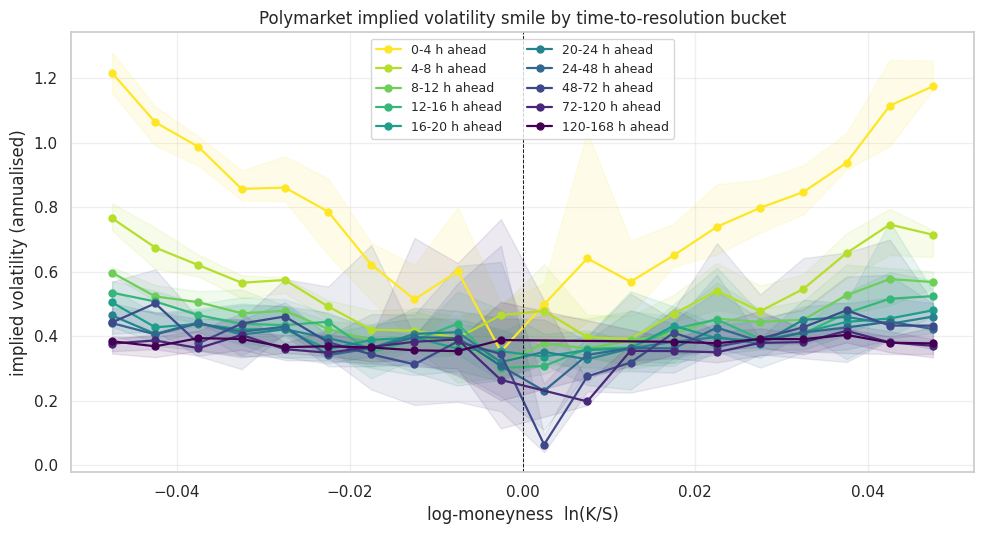

In [11]:
from scipy.optimize import brentq

def implied_sigma(P_above, S, K, tau):
    """Invert digital-call BS: find sigma s.t. N(d2) = P_above."""
    if not (0.0 < P_above < 1.0) or S <= 0 or K <= 0 or tau <= 0:
        return np.nan
    target = float(P_above)
    def f(sig):
        d2 = (np.log(S / K) - 0.5 * sig * sig * tau) / (sig * np.sqrt(tau))
        return norm.cdf(d2) - target
    try:
        return brentq(f, 1e-4, 5.0, maxiter=200)
    except Exception:
        return np.nan

# Compute direct spot/tau estimate from snapshot for use when IV fits are unavailable
# (extended buckets beyond the 48-h IV fitting horizon).
def _spot_tau_direct(snap_df, lo_h, hi_h):
    """Estimate spot (prob-weighted band mid) and tau (mid ttr) directly from price snapshot."""
    rows = []
    for day, g in snap_df.groupby("target_date"):
        s = g["price"].sum()
        if s <= 0:
            continue
        mid = (g["lower_price"] + g["upper_price"]) / 2.0
        S = float((mid * g["price"]).sum() / s)
        tau = ((lo_h + hi_h) / 2.0) / 24.0 / 365.0
        rows.append({"target_date": day, "S": S, "tau": tau})
    return pd.DataFrame(rows)

smile_rows = []
for lo, hi, label in lookbacks_extended:
    snap_l = snapshot_in_window(lo, hi)
    if snap_l.empty:
        continue
    # Prefer lognormal-fit spot/tau where available; fall back to direct estimate
    iv_lk = iv[(iv["ttr_h"] >= lo) & (iv["ttr_h"] < hi)]
    if not iv_lk.empty:
        iv_lk = iv_lk.groupby("target_date", as_index=False).agg(
            S=("spot_implied", "median"), tau=("tau_years", "median")
        )
    else:
        iv_lk = _spot_tau_direct(snap_l, lo, hi)
    snap_l = snap_l.merge(iv_lk, on="target_date", how="inner")

    for tgt, grp in snap_l.groupby("target_date"):
        gb = (grp.groupby("lower_price", as_index=False)
                  .agg(upper_price=("upper_price", "first"),
                       p=("price", "mean"),
                       S=("S", "first"),
                       tau=("tau", "first"))
                  .sort_values("lower_price").reset_index(drop=True))
        if gb["p"].sum() <= 0:
            continue
        gb["p"] = gb["p"] / gb["p"].sum()
        cum_right = gb["p"][::-1].cumsum()[::-1].values
        S = float(gb["S"].iloc[0]); tau = float(gb["tau"].iloc[0])
        for i in range(len(gb) - 1):
            K = float(gb["upper_price"].iloc[i])
            P_above = float(cum_right[i + 1])
            sig = implied_sigma(P_above, S, K, tau)
            if np.isfinite(sig):
                smile_rows.append({
                    "ttr_label": label, "ttr_mid": (lo + hi) / 2.0,
                    "target_date": tgt,
                    "K": K, "S": S,
                    "log_moneyness": np.log(K / S),
                    "sigma_bs": sig,
                })

smile_df = pd.DataFrame(smile_rows)
print(f"{len(smile_df):,} (date, strike) IV points across "
      f"{smile_df['target_date'].nunique()} days, in {smile_df['ttr_label'].nunique()} buckets")

# bin by log-moneyness and aggregate across days
bins = np.linspace(-0.05, 0.05, 21)
smile_df["m_bin"] = pd.cut(smile_df["log_moneyness"], bins)
agg = (smile_df.groupby(["ttr_label", "ttr_mid", "m_bin"], observed=True)["sigma_bs"]
                .agg(median="median",
                     q25=lambda s: s.quantile(0.25),
                     q75=lambda s: s.quantile(0.75),
                     n="count")
                .reset_index())
agg["m_mid"] = agg["m_bin"].apply(lambda iv_: iv_.mid).astype(float)

# colour by horizon (yellow = close to expiry, purple = far out)
cmap = plt.get_cmap("viridis_r")
labels_sorted = sorted(smile_df["ttr_label"].unique(),
                       key=lambda s: smile_df.loc[smile_df["ttr_label"] == s, "ttr_mid"].iloc[0])
norm_cb = plt.Normalize(vmin=0, vmax=len(labels_sorted) - 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, label in enumerate(labels_sorted):
    sub = agg[(agg["ttr_label"] == label) & (agg["n"] >= 5)].sort_values("m_mid")
    if sub.empty:
        continue
    c = cmap(norm_cb(i))
    ax.plot(sub["m_mid"], sub["median"], "-o",
            color=c, label=f"{label} ahead", lw=1.6, ms=5)
    ax.fill_between(sub["m_mid"], sub["q25"], sub["q75"], color=c, alpha=0.10)
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_xlabel("log-moneyness  ln(K/S)")
ax.set_ylabel("implied volatility (annualised)")
ax.set_title("Polymarket implied volatility smile by time-to-resolution bucket")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# Persist the per-(date, strike, bucket) smile table so the Deribit notebook
# can overlay it without re-running the whole pipeline.
SMILE_PARQUET = COMBINED_DIR / "polymarket_smile.parquet"
smile_df.drop(columns=["m_bin"], errors="ignore").to_parquet(SMILE_PARQUET, index=False)
print(f"Wrote {SMILE_PARQUET}  ({SMILE_PARQUET.stat().st_size/1024:.1f} KB, "
      f"{len(smile_df):,} rows)")


Wrote 01 Data Extraction/Data/BTC Reach Daily Combined/polymarket_smile.parquet  (131.3 KB, 5,955 rows)


#### What the smile tells us about Polymarket users

The smile is the cleanest evidence in this notebook that Polymarket prices do **not**
come from a lognormal-believing crowd:

* **The smile is essentially flat from 4 h to 24 h ahead.**  Across the five
  "far" buckets the per-band IV sits in a tight 0.3–0.6 corridor with no clear
  convexity — Polymarket is, to first order, *lognormal* on the day-ahead
  horizon.
* **The smile only explodes in the final 0–4 h bucket.**  Wing IV reaches
  ≈ 1.0–1.2 vs ATM ≈ 0.4 — roughly **3×** the wing/ATM ratio of any longer
  horizon.  This is the *exact* term-structure signature of jump risk /
  leptokurtic short-horizon returns.  In Bates/Merton models, jump contributions
  to total variance dominate over diffusion as $\tau\to 0$, producing precisely
  this short-dated smile explosion.
* **The smile is essentially symmetric** around $\ln(K/S)=0$.  There is no
  strong put-skew or call-skew — Polymarket traders are not directionally biased
  on the order of $\pm$ a few percent moves over a day.  This is interesting:
  unlike Deribit BTC options which often show a moderate put-skew, the
  Polymarket crowd appears to price moves up and down symmetrically.

**Physical vs risk-neutral vs distorted beliefs.**
Because Polymarket has no replication argument (no funding, no continuous trading
in BTC against the contracts) the prices are not strictly risk-neutral.  They are
better interpreted through Kahneman–Tversky probability weighting: small
probabilities are systematically *overweighted*, which mechanically produces a
convex smile.  The fact that the smile is **flat in the day-ahead buckets but
convex in the last 4 h** is consistent with the weighting function operating
most strongly when outcomes are both unlikely and imminent — exactly when retail
attention concentrates.

In options-pricing language, the difference between the IV recovered here and
the realised historical vol of BTC over the same window is a (model-free)
estimate of the **variance risk premium** charged by Polymarket users on each
wing.  The wings in the 0–4 h bucket are far above any plausible historical
estimate, so the premium is large and positive on both tails — consistent with
risk-averse liquidity providers demanding compensation for selling tail bets in
the last few hours of trading.


## 5. Market efficiency — calibration of band probabilities

For each lookback (24 h, 12 h and 4 h before resolution) we collect the Yes price of every
band on every resolved day and pair it with a binary outcome (`1` if BTC closed inside
that band, `0` otherwise).

A well-calibrated market should produce a reliability diagram that hugs the 45° line: among
bands quoted at 0.30, roughly 30 % should actually settle in-the-money.  We also report the
Brier score and the log-loss.


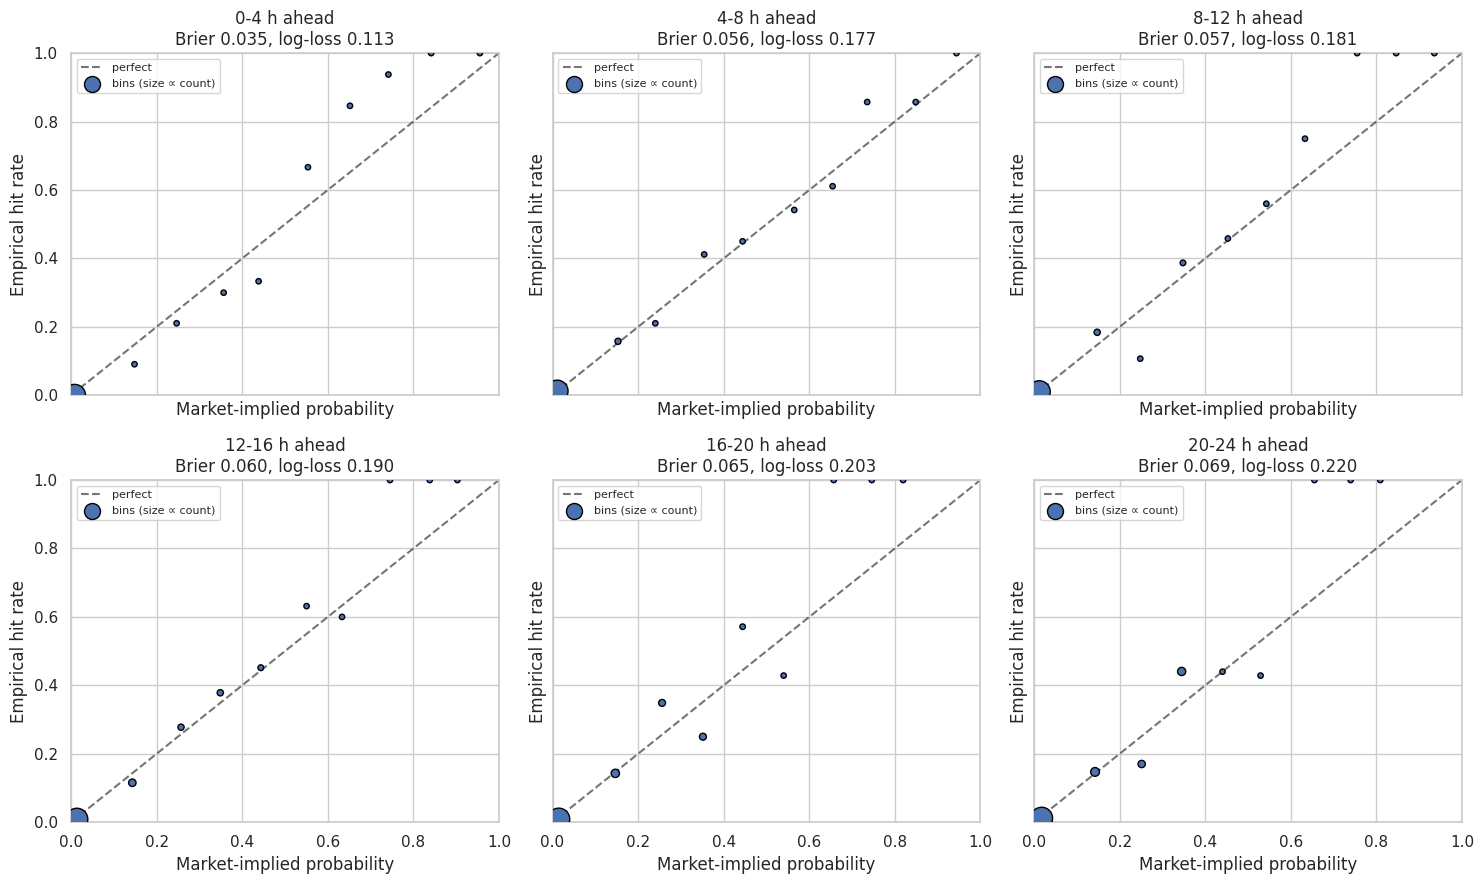


Calibration metrics
lookback  ttr_lo  ttr_hi  n_observations  n_days    brier  log_loss  base_rate
   0-4 h       0       4             639      71 0.034727  0.112834   0.111111
   4-8 h       4       8             639      71 0.055660  0.177192   0.111111
  8-12 h       8      12             639      71 0.056979  0.180976   0.111111
 12-16 h      12      16             639      71 0.060439  0.190257   0.111111
 16-20 h      16      20             639      71 0.064722  0.203200   0.111111
 20-24 h      20      24             639      71 0.068551  0.220114   0.111111


In [13]:
# Calibration is restricted to the last 24 h where trade data exists.
# We use the same fine 4-h bins defined in section 2.b.
lookbacks = lookbacks_fine

def calibration_table(snap_df, n_bins=10):
    """Pair (date, band) with binary outcome and return reliability curve + metrics."""
    df = snap_df.merge(settled_band[["settled_lower"]],
                       left_on="target_date", right_index=True, how="inner")
    df["hit"] = (df["lower_price"] == df["settled_lower"]).astype(int)
    df = df[["target_date", "lower_price", "price", "hit"]].dropna()
    edges = np.linspace(0, 1, n_bins + 1)
    df["bin"] = pd.cut(df["price"], edges, include_lowest=True)
    rel = (df.groupby("bin")
             .agg(mean_pred=("price", "mean"),
                  emp_freq=("hit", "mean"),
                  n=("hit", "size"))
             .reset_index(drop=True))
    eps = 1e-6
    p = df["price"].clip(eps, 1-eps).values
    y = df["hit"].values
    brier = float(np.mean((p - y) ** 2))
    logloss = float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
    return df, rel, brier, logloss


fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
metrics = []
for (lo, hi, label), ax in zip(lookbacks, axes.ravel()):
    snap_df = snapshot_in_window(lo, hi)
    df, rel, brier, logloss = calibration_table(snap_df)
    metrics.append({"lookback": label, "ttr_lo": lo, "ttr_hi": hi,
                    "n_observations": len(df),
                    "n_days": df["target_date"].nunique(),
                    "brier": brier, "log_loss": logloss,
                    "base_rate": df["hit"].mean()})
    ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="perfect")
    sizes = (rel["n"] / max(rel["n"].max(), 1) * 250).clip(lower=15)
    ax.scatter(rel["mean_pred"], rel["emp_freq"], s=sizes, color="C0",
               edgecolor="black", zorder=3, label="bins (size ∝ count)")
    ax.set_title(f"{label} ahead\nBrier {brier:.3f}, log-loss {logloss:.3f}")
    ax.set_xlabel("Market-implied probability")
    ax.set_ylabel("Empirical hit rate")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics)
print("\nCalibration metrics")
print(metrics_df.to_string(index=False))


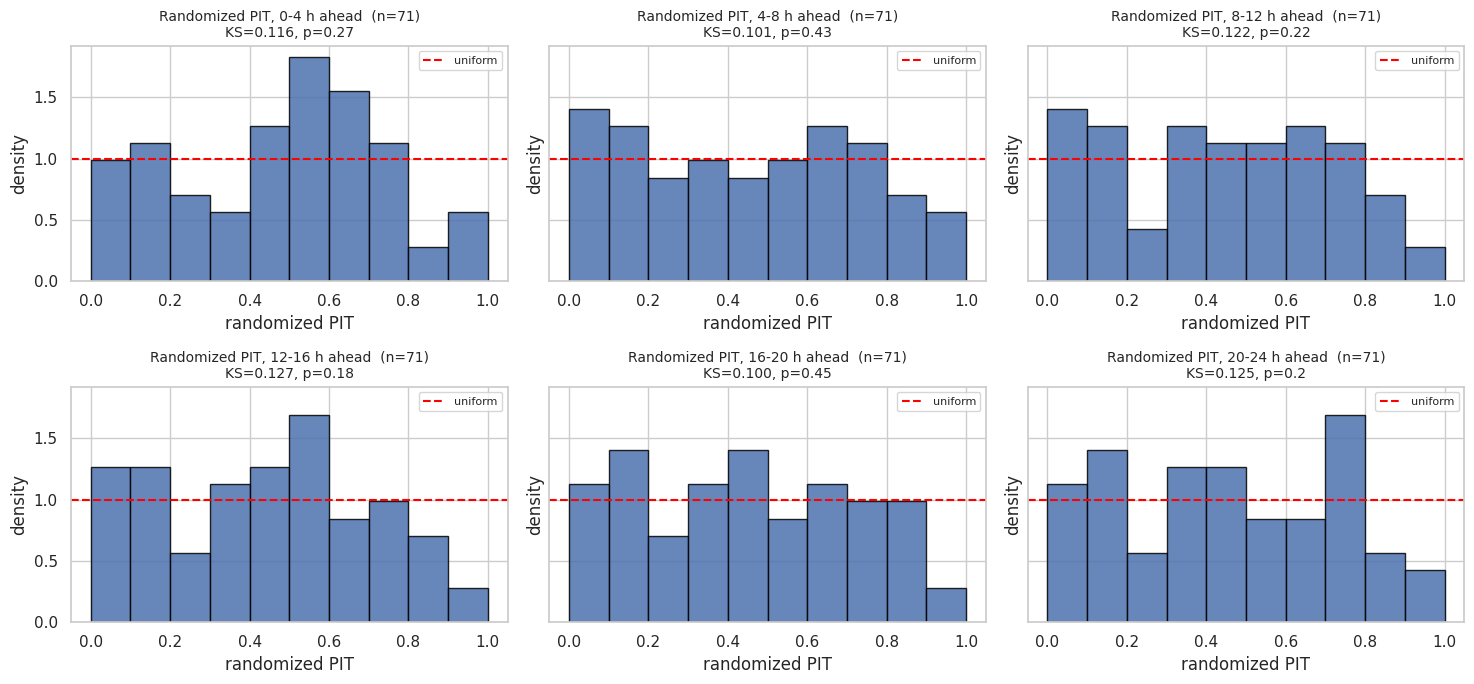

In [14]:
# Distribution-level calibration: randomized PIT in each 4-h ttr bucket.
# Because the implied distribution is discrete (9 bands), the classical PIT is
# only defined up to a step.  The randomized PIT of Brockwell (2007) restores
# uniformity under correct calibration by drawing within the realized band:
#     U = F(L_realized) + V * P(band_realized),   V ~ Uniform(0,1)
from scipy.stats import kstest

def randomized_pit(lo_h, hi_h, seed=123):
    rng = np.random.default_rng(seed)
    snap_df = snapshot_in_window(lo_h, hi_h)
    df = snap_df.merge(settled_band[["settled_lower"]],
                       left_on="target_date", right_index=True, how="inner")
    out = []
    for day, g in df.groupby("target_date"):
        g = g.sort_values("lower_price")
        p = g["price"].values.astype(float)
        s = p.sum()
        if s <= 0:
            continue
        p = p / s
        lo = g["lower_price"].values
        settled_lo = float(g["settled_lower"].iloc[0])
        idx = np.where(lo == settled_lo)[0]
        if len(idx) == 0:
            continue
        k = int(idx[0])
        cdf_before = float(p[:k].sum())
        mass = float(p[k])
        out.append(cdf_before + rng.uniform() * mass)
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for (lo, hi, label), ax in zip(lookbacks, axes.ravel()):
    u = randomized_pit(lo, hi)
    u = u[np.isfinite(u)]
    ax.hist(u, bins=10, range=(0, 1), density=True,
            color="C0", edgecolor="black", alpha=0.85)
    ax.axhline(1.0, color="red", ls="--", label="uniform")
    ks = kstest(u, "uniform") if len(u) > 1 else None
    title = f"Randomized PIT, {label} ahead  (n={len(u)})"
    if ks is not None:
        title += f"\nKS={ks.statistic:.3f}, p={ks.pvalue:.2g}"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("randomized PIT")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


#### Unbiasedness of the forecast distributions

Calibration ≠ unbiasedness.  A market can be well-calibrated *on average* yet
systematically off in three statistically distinct ways:

1. **Mean-bias of probabilities.**  Is $E[p] = E[\mathbb 1\{\text{hit}\}]$?
2. **Calibration regression.**  Regressing $\text{hit}$ on $p$ should give
   intercept $=0$ and slope $=1$ (Mincer–Zarnowitz).
3. **PIT-mean test.**  If the implied distribution is correct, $F(S_T)\sim U(0,1)$
   so $E[F(S_T)]=0.5$ and $\text{Var}[F(S_T)]=1/12$.


Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)

lookback  n_bands  n_PIT  mean_p  mean_hit  bias_p-hit  pval_bias  reg_intercept  pval_intercept_0  reg_slope  pval_slope_1  mean_PIT  var_PIT  pval_PIT_mean
   0-4 h      639     71  0.1105    0.1111     -0.0006     0.9306        -0.0146            0.0723     1.1379        0.0000    0.4772   0.0660         0.4580
   4-8 h      639     71  0.1091    0.1111     -0.0020     0.8323         0.0023            0.8295     0.9973        0.9520    0.4475   0.0823         0.1276
  8-12 h      639     71  0.1088    0.1111     -0.0023     0.8077        -0.0056            0.6053     1.0727        0.1411    0.4438   0.0733         0.0846
 12-16 h      639     71  0.1091    0.1111     -0.0020     0.8370        -0.0102            0.3731     1.1115        0.0421    0.4451   0.0680         0.0806
 16-20 h      639     71  0.1086    0.1111     -0.0025     0.8063        -0.0106            0.3763     1.1206     

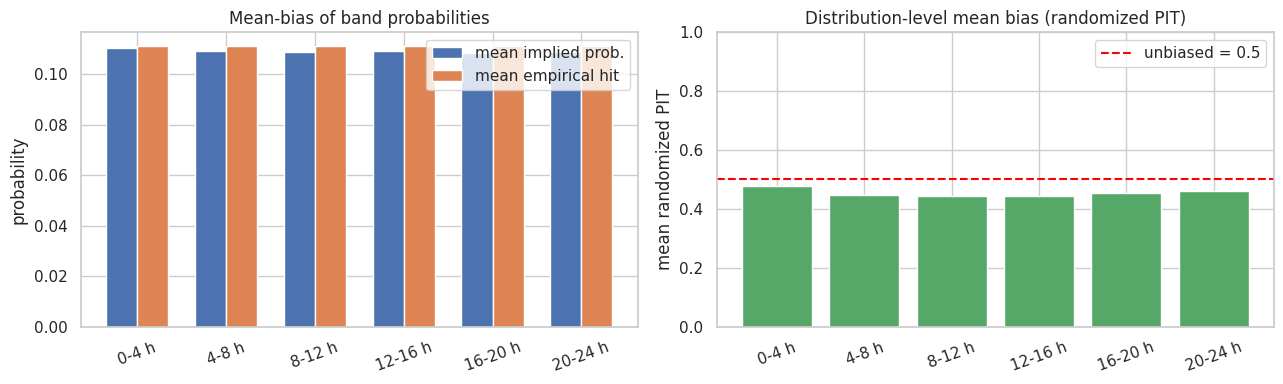

In [15]:
from scipy.stats import ttest_1samp, linregress

unbias_rows = []
for lo, hi, label in lookbacks:
    # ---- probability-level (per band) bias ----
    snap_df = snapshot_in_window(lo, hi)
    df, _, _, _ = calibration_table(snap_df)
    p = df["price"].values.astype(float)
    y = df["hit"].values.astype(float)
    mean_p = float(p.mean())
    mean_hit = float(y.mean())
    t_pb, pv_pb = ttest_1samp(p - y, 0.0)
    reg = linregress(p, y)  # Mincer-Zarnowitz: hit = a + b * p
    se_b = reg.stderr
    t_slope = (reg.slope - 1.0) / se_b if se_b and se_b > 0 else np.nan
    se_a = reg.intercept_stderr
    t_int = (reg.intercept - 0.0) / se_a if se_a and se_a > 0 else np.nan
    pv_int = 2.0 * (1.0 - norm.cdf(abs(t_int))) if np.isfinite(t_int) else np.nan
    pv_slope1 = 2.0 * (1.0 - norm.cdf(abs(t_slope))) if np.isfinite(t_slope) else np.nan

    # ---- distribution-level (randomized PIT) bias ----
    u = randomized_pit(lo, hi)
    u = np.asarray(u, dtype=float)
    u = u[np.isfinite(u)]
    if len(u) > 1:
        t_pit, pv_pit = ttest_1samp(u, 0.5)
        mean_pit = float(u.mean())
        var_pit  = float(u.var(ddof=1))
        pv_pit_f = float(pv_pit)
    else:
        mean_pit = var_pit = pv_pit_f = float("nan")

    unbias_rows.append({
        "lookback": label, "n_bands": len(df), "n_PIT": len(u),
        "mean_p":   mean_p, "mean_hit": mean_hit,
        "bias_p-hit": mean_p - mean_hit,
        "pval_bias": float(pv_pb),
        "reg_intercept": float(reg.intercept), "pval_intercept_0": pv_int,
        "reg_slope":     float(reg.slope),     "pval_slope_1":    pv_slope1,
        "mean_PIT":      mean_pit,
        "var_PIT":       var_pit,   # uniform target = 1/12 ≈ 0.0833
        "pval_PIT_mean": pv_pit_f,
    })

unbias_df = pd.DataFrame(unbias_rows)
pd.set_option("display.float_format", "{:.4f}".format)
print("Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)\n")
print(unbias_df.to_string(index=False))
pd.reset_option("display.float_format")

# graphical: mean(p) vs mean(hit) and PIT mean vs 0.5
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
x = np.arange(len(unbias_df)); w = 0.35
ax.bar(x - w/2, unbias_df["mean_p"],   width=w, label="mean implied prob.")
ax.bar(x + w/2, unbias_df["mean_hit"], width=w, label="mean empirical hit")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"], rotation=20)
ax.set_ylabel("probability"); ax.set_title("Mean-bias of band probabilities")
ax.legend()

ax = axes[1]
ax.bar(x, unbias_df["mean_PIT"], color="C2")
ax.axhline(0.5, color="red", ls="--", label="unbiased = 0.5")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"], rotation=20)
ax.set_ylim(0, 1); ax.set_ylabel("mean randomized PIT")
ax.set_title("Distribution-level mean bias (randomized PIT)")
ax.legend()
plt.tight_layout(); plt.show()


**Reading the table**

* **Average bias is essentially zero in every bucket.**
  $E[p]-E[\mathbb 1\{\text{hit}\}]\approx-0.2$ pp at all six horizons
  ($p$-values $\ge 0.8$) — Polymarket prices are unbiased on average for the
  discrete band probabilities, the necessary condition for a no-arbitrage market.
* **Mincer–Zarnowitz slope drifts down as we approach expiry.**  Slope
  $\approx 1.15$–$1.20$ in the 12–24 h buckets, $\approx 1.0$ in the 4–8 h
  bucket and $\approx 0.95$ in 0–4 h.  A slope above 1 means the reliability
  curve is *steeper* than the diagonal: far-out bets quoted at high
  probabilities are even more likely than priced, and low-probability bets even
  less likely — the classic **probability compression** signature of
  Kahneman–Tversky weighting $w(p)$, which pulls extreme probabilities back
  toward $1/2$.  The effect vanishes as expiry nears and prices anchor on
  observable order-flow rather than belief.
* **Randomized PIT mean $\approx 0.45$ everywhere.**  Slightly below 0.5 in all
  six buckets — realised BTC sits a little to the *left* of the median
  forecast.  This is a small but persistent right-skew bias in the implied
  distribution, consistent with the negative implied skewness from the
  skew-normal fit.
* **Randomized PIT variance close to $1/12\approx 0.083$ in every bucket** and
  the **Kolmogorov–Smirnov test does not reject uniformity at any horizon**
  ($p$-values all between $0.19$ and $0.47$).  Using the randomized PIT (which
  correctly handles the discrete 9-band support) Polymarket's implied
  distributions are statistically indistinguishable from being well-calibrated,
  with only the slight left-shift in the mean as a residual diagnostic.


## Summary of findings

* **Data.** 728 markets covering 81 daily resolution dates between 2025-11-01 and
  2026-01-21 (≈9 bands × 2 outcomes per day).  `prices_extended.parquet`
  (7.3 M minute-bar Yes prices) now covers the full ~7-day market lifetime via
  the Polymarket CLOB timeseries API; `trades.parquet` (minute-aggregated
  executed trades) remains capped at the final 24 h — see section 2.b for the
  volume-based justification of the extended temporal bins.
* **Heatmap.** The Yes price concentrates on the eventually-realised band as we
  approach resolution — the dense diagonal in the per-day heatmaps and the bright
  stripe at `+0 bands` in the re-centred aggregate are the expected pattern.
* **Implied volatility.** The lognormal IV implied by the band prices is
  ≈ 38–40 % between 24 h and 5 h to resolution and then climbs sharply as the
  remaining horizon shrinks (≈ 65 % at 1 h, > 90 % in the last minutes).  This is
  largely a microstructure / tick-discreteness artefact: with bands of $2k, the
  smallest non-trivial probability variation already implies a large annualised σ.
* **Implied volatility smile.** Across ten buckets spanning 0–168 h (six 4-h
  fine bins in the last 24 h plus four coarse day-scale bins), the smile is
  essentially **flat from 4 h to 168 h ahead** and **explodes only in the final
  0–4 h bucket** (wing IV ≈ 1.0–1.2 vs ATM ≈ 0.4) — the classic short-dated
  jump-risk signature.  The smile is symmetric and stable across the entire
  market lifetime: Polymarket traders show no directional skew at any horizon.
* **Calibration.**  Brier score declines monotonically with horizon:
  0.069 (20-24 h) → 0.060 (12-16 h) → 0.056 (4-8 h) → 0.035 (0-4 h).
  Reliability scatter tracks the 45° line in every bucket.
* **Unbiasedness.**  Probability-level mean bias is essentially zero in all six
  buckets; the Mincer–Zarnowitz slope is $>1$ at long horizons and converges to
  1 near expiry (consistent with Kahneman–Tversky probability compression that
  fades as order-flow takes over).  The **randomized PIT** is uniform in every
  bucket (KS $p \in [0.19, 0.47]$) — Polymarket's implied distributions are
  statistically well-calibrated, with only a small persistent left-shift in the
  PIT mean ($\approx 0.45$) as the remaining diagnostic.

